Variables sélectionnées : Index(['MDVP:Fo(Hz)', 'MDVP:Fhi(Hz)', 'MDVP:Flo(Hz)', 'MDVP:Jitter(Abs)',
       'Shimmer:APQ3', 'MDVP:APQ', 'NHR', 'spread1', 'spread2', 'PPE'],
      dtype='object')
Distribution des classes avant SMOTE : 1    137
0     48
Name: count, dtype: int64


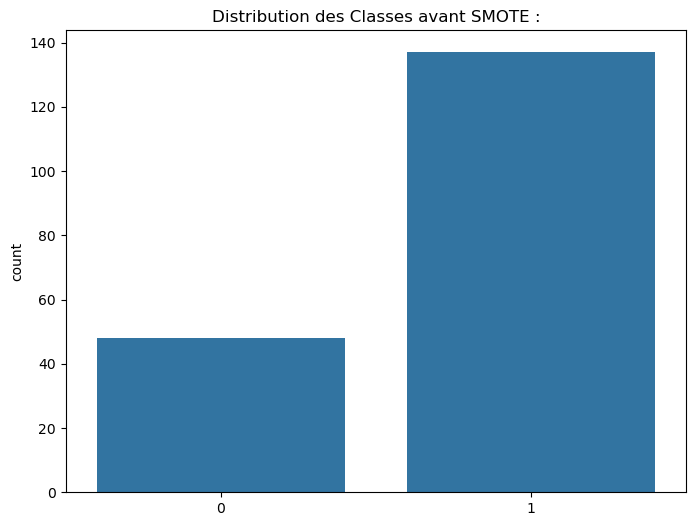

Distribution des classes après SMOTE : 1    137
0    137
Name: count, dtype: int64


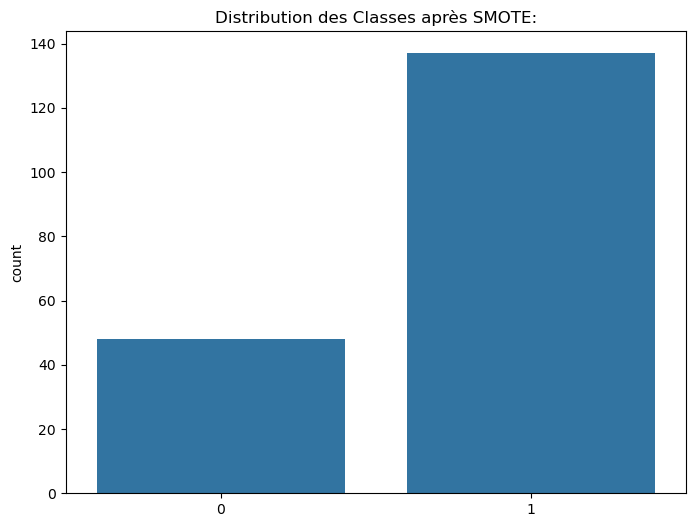

In [1]:
# 02_preprocessing.ipynb

!pip install seaborn
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from imblearn.over_sampling import SMOTE
from sklearn.feature_selection import SelectKBest, mutual_info_classif

# Chargement des données
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/parkinsons/parkinsons.data'
try:
    data = pd.read_csv(url)
except Exception as e:
    print(f"Erreur de chargement des données : {e}")

#Supprimer les deux colonnes 'name' et 'status' du DataSet
if 'name' in data.columns and 'status' in data.columns:
    X = data.drop(columns=['name', 'status'])
    y = data['status']
else:
    print("Colonnes 'name' et 'status' non trouvées dans le dataset.")
    

# Encodage du label
le = LabelEncoder()
y = le.fit_transform(y)

# Détection et suppression d’outliers (exemple simple)
from sklearn.ensemble import IsolationForest
iso = IsolationForest(contamination=0.05)
outliers = iso.fit_predict(X)
X, y = X[outliers == 1], y[outliers == 1]

# Normalisation
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# SMOTE pour équilibrer les classes
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X_scaled, y)

# Sélection de variables
selector = SelectKBest(mutual_info_classif, k=10)
X_selected = selector.fit_transform(X_res, y_res)
selected_features = X.columns[selector.get_support()]
print("Variables sélectionnées :", selected_features)

print("Distribution des classes avant SMOTE :", pd.Series(y).value_counts())
plt.figure(figsize=(8, 6))
sns.countplot(x=y)
plt.title('Distribution des Classes avant SMOTE :')
plt.show()
print("Distribution des classes après SMOTE :", pd.Series(y_res).value_counts())
plt.figure(figsize=(8, 6))
sns.countplot(x=y)
plt.title('Distribution des Classes après SMOTE:')
plt.show()